In [1]:
%load_ext autoreload
%autoreload 2

import os
import jax

import numpy as np
from flax import serialization

from c3po.analysis.analysis import C3poAnalysis
from c3po.model.model import C3PO

# analysis=C3poAnalysis(None, None, None)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# Load data

In [2]:
import numpy as np
from scipy.io import loadmat

data_name = "/stelmo/sam/c3po_results/moserdata.mat"
# data_name = "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"


data = loadmat(
    data_name
    # "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"
)  # in the downloadable Vollan archive, this is 27765_2.mat  (potentially can do this with any other data file)


def mat_fields(s):
    """Return field names for a MATLAB struct (np.void or structured ndarray)."""
    if isinstance(s, np.ndarray) and s.dtype.names:
        return s.dtype.names
    if isinstance(s, np.void) and s.dtype.names:
        return s.dtype.names
    raise TypeError("Not a MATLAB struct (np.void/structured ndarray).")


# The 'Dsession' key gives the main struct
Dsession = data["Dsession"]

t = Dsession["t"][0, 0].flatten()  # times
x = Dsession["x"][0, 0].flatten()  # x positions
y = Dsession["y"][0, 0].flatten()  # y positions
speed = Dsession["speed"][0, 0].flatten()  #
thetaphase = Dsession["theta"][0, 0].flatten()  #
units = Dsession["units"][0, 0].flatten()  # unit data (more parsing below)
unit_cluster_id = units["mec"][0]["acorrCluId"][:]

head_dir = Dsession["hd"][0, 0].flatten()
hd_cont = np.unwrap(head_dir)
ang_vel = np.gradient(hd_cont, np.median(np.diff(t)))
ind_jump = np.where(np.diff(t) > 0.1)[0]
ang_vel[ind_jump] = 0
ang_vel[ind_jump + 1] = 0

In [3]:
mat_fields(units["mec"][0])

('id',
 'ks2Label',
 'location',
 'meanRate',
 'nSpikes',
 'probeId',
 'shank',
 'shankPos',
 'spikeInds',
 'spikeTimes',
 'wvExtent',
 'lmtF',
 'rmc',
 'rmf',
 'smdl',
 'wv',
 'cellType',
 'acorrClu',
 'isGrid',
 'acorrCluId')

In [4]:
t_spikes = np.arange(t[0], t[-1], 0.002)
spikes = []
for uu in range(len(units["mec"][0]["spikeTimes"])):
    spikes.append(units["mec"][0]["spikeTimes"][uu][0].flatten())

len(spikes)


from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

smoothing_window = 0.02  # in seconds
smoothing_window = 0.003  # in seconds
dt = t_spikes[1] - t_spikes[0]
smoothing_window_bins = int(smoothing_window / dt)
rates = []

for uu in tqdm(range(len(spikes))):
    rate, _ = np.histogram(
        spikes[uu], bins=np.concatenate([t_spikes, [t_spikes[-1] + (dt)]])
    )
    # rate = np.convolve(
    #     rate,
    #     np.ones(smoothing_window_bins) / smoothing_window_bins,
    #     mode="same",
    # )
    rate = gaussian_filter1d(
        rate[:, None].astype("float"),
        sigma=smoothing_window_bins,
        axis=0,
        mode="nearest",
    )

    rates.append(rate / (t[1] - t[0]))  # in Hz
rates = np.squeeze(rates).T
mua = rates.sum(axis=1)

100%|██████████| 460/460 [00:22<00:00, 20.50it/s]


In [5]:
# plt.hist(np.log10(np.diff(t)))
# plt.yscale("log")
# np.median(np.diff(t))
dt = np.diff(t)

ind_valid = (dt < 0.02).astype(int)  # only use intervals with dt < 20 ms
starts = np.where(np.diff(ind_valid) == 1)[0] + 1
ends = np.where(np.diff(ind_valid) == -1)[0] + 1
if ind_valid[0]:
    starts = np.insert(starts, 0, 0)
if ind_valid[-1]:
    ends = np.append(ends, len(ind_valid))
valid_intervals = [[t[s], t[e]] for s, e in zip(starts, ends)]

In [6]:
def angular_distance(ang, ref_ang):
    """
    Compute signed angular distance between two angles (in radians).
    Returns a value in [-π, π].
    """
    delta = np.arctan2(np.sin(ang - ref_ang), np.cos(ang - ref_ang))
    return delta


# t            = Dsession["t"][0, 0].flatten()  # times   (100 Hz sampling)
hd_lmt = Dsession["lmt"][0][0][0][0][0]["hd"][0][0]["XA"][0][0].flatten()
id_lmt = Dsession["lmt"][0][0][0][0][0]["id"][0][0]["XA"][0][0].flatten()
pos_lmt = Dsession["lmt"][0][0][0][0][0]["pos"][0][0]["XA"][0][0]

# calculate decode errors #
moser_hd_error = angular_distance(id_lmt, head_dir)
moser_pos_error = np.sqrt((pos_lmt[:, 0] - x) ** 2 + (pos_lmt[:, 1] - y) ** 2)

# Load c3po

In [7]:
from c3po.tables.dev_tables import C3POStorage
import matplotlib.pyplot as plt

C3POStorage()  # .alter()
model_name = "mec_wavenet_25843_all_cells"
model_name = "mec_wavenet_all_cells"


# model_name = "moser_mec_29502_1_openfield_wavenet_all_cells"
# model_name = f"mec_{data_name.split('/')[-1].split('.')[0]}_jan2026"

# key = {"model_name": "mec_wavenet_all_cells"}
key = dict(model_name=model_name)

analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")

diff_t = np.diff(analysis.t)
bad_diff = np.where(diff_t > 0.1)[0] + 1
bad_diff = np.concatenate([[0], bad_diff, np.array([len(analysis.t)])])
no_gap_intervals = []
for i in range(len(bad_diff) - 1):
    no_gap_intervals.append((analysis.t[bad_diff[i]], analysis.t[bad_diff[i + 1] - 1]))
no_gap_intervals = np.array(no_gap_intervals)[:-7]

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(fit_intervals=no_gap_intervals[5:], interpolated=False)

# Just showing how to access the variables
# t = analysis.t
z = analysis.z
c = analysis.c
c_pca = analysis.c_pca
t_interp = analysis.t_interp
c_interp = analysis.c_interp
c_pca_interp = analysis.c_pca_interp

entry = (C3POStorage & key).fetch1()
latent_dim = entry["latent_dim"]
context_dim = entry["context_dim"]

# define figure directory
from c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig3" / "mec_open_field" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # to get editable text in Illustrator

[2026-06-01 09:07:14,404][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [ ]:
interpolated_pca = False

# filter c3po frequency bands

In [132]:
# filter context variables #

from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt

# simple gaussian filter #
sigma = 15  # in ms
c_smooth = gaussian_filter1d(analysis.c_pca_interp, sigma=sigma, axis=0)

# butterworth filters #
c_filt = []

#  < 1.5 Hz #   0
b, a = butter(2, 1 / (500), btype="lowpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

#  1.5 to 18 Hz #       1
b, a = butter(2, [1.5 / (500), 18 / (500)], btype="bandpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

#  2 to 4.5 Hz #          2
b, a = butter(2, [2 / (500), 4.5 / (500)], btype="bandpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

#  5 to 10 Hz #      3      # Vollan Moser
b, a = butter(2, [5 / (500), 10 / (500)], btype="bandpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

#  12 to 20 Hz #      4
b, a = butter(2, [12 / (500), 20 / (500)], btype="bandpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

#  2.5 to 11 Hz #      5
b, a = butter(2, [2.5 / (500), 11 / (500)], btype="bandpass")
c_filt.append(filtfilt(b, a, analysis.c_pca_interp, axis=0))

# Calculate c3po phase

In [130]:
Theta_cvars = (0, 3)

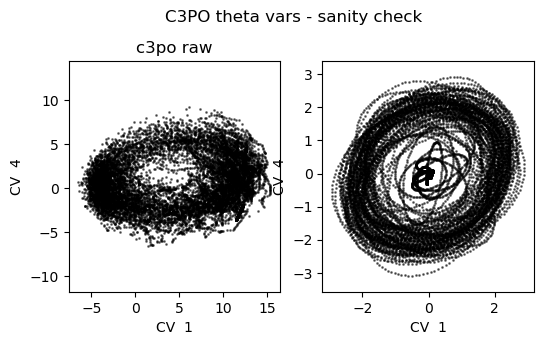

In [133]:
########### Calculate C3PO theta ##################

# raw c3po theta #
cv_theta_1_raw = analysis.c_pca_interp[:, Theta_cvars[0]]
cv_theta_2_raw = analysis.c_pca_interp[:, Theta_cvars[1]]

# get filtered data #
cv_theta_1 = c_filt[3][:, Theta_cvars[0]]
cv_theta_2 = c_filt[3][:, Theta_cvars[1]]

# zscore normalize #
cv_theta_1_z = (cv_theta_1 - np.mean(cv_theta_1)) / np.std(cv_theta_1)
cv_theta_2_z = (cv_theta_2 - np.mean(cv_theta_2)) / np.std(cv_theta_2)

# arctan 'decoder' #
theta_c3po = np.arctan2(cv_theta_1_z.copy(), cv_theta_2_z.copy())
theta_c3po_raw = np.arctan2(cv_theta_1_raw.copy(), cv_theta_2_raw.copy())

######## (sanity check) plot scatter C3PO theta latents, raw + z-scored ###########
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
for a in ax:
    if a == ax[0]:
        cv1 = cv_theta_1_raw
        cv2 = cv_theta_2_raw
        a.set_title("c3po raw")
    elif a == ax[1]:
        cv1 = cv_theta_1_z
        cv2 = cv_theta_2_z
        # a.hlines(0, xmin=-1, xmax=1, color='r', lw = 2, linestyle='-', alpha=.5, zorder=99)
        # a.vlines(0, ymin=-1, ymax=1, color='r', lw = 2, linestyle='-', alpha=.5, zorder=999)
        # a.plot(np.cos(theta_c3po[:99000]), np.sin(theta_c3po[:99000]), '-', color='r' , alpha=0.2)
        # a.set_title('c3po z filt')
    a.scatter(cv1[:15000], cv2[:15000], color="k", s=1, alpha=0.5)
    a.set_xlabel(f"CV  {Theta_cvars[0]+1}")
    a.set_ylabel(f"CV  {Theta_cvars[1]+1}")
    a.axis("equal")
    # a.set_xlim(np.min(cv1)-0.5, np.max(cv1)+0.5)
    # a.set_ylim(np.min(cv2)-0.5, np.max(cv2)+0.5)
plt.suptitle("C3PO theta vars - sanity check", y=1.05)
plt.show()

# SB comparison: MUA

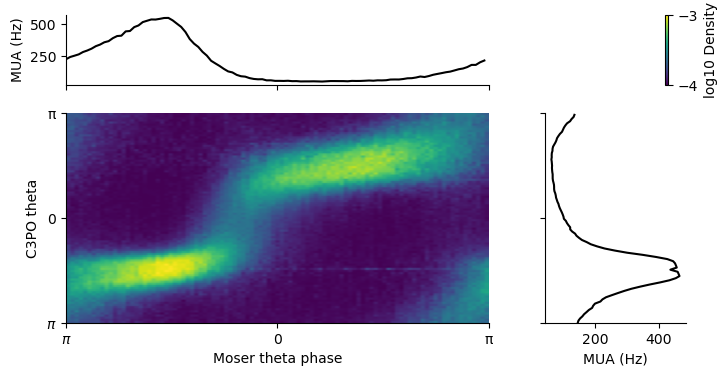

In [30]:
# theta_c3po.shape, analysis.t_interp.shape, thetaphase.shape

from c3po.analysis.analysis import interval_list_contains_ind

ind_valid = interval_list_contains_ind(no_gap_intervals, analysis.t_interp)

t_c3po = analysis.t_interp[ind_valid]
theta_c3po_valid = theta_c3po_raw[ind_valid]

moser_ind = np.digitize(t_c3po, t, right=False)
moser_theta = thetaphase[moser_ind]

ind_spikes = np.digitize(t_c3po, t_spikes, right=False)
mua_aligned = mua[ind_spikes]

H, bx, by = np.histogram2d(
    moser_theta, theta_c3po_valid, bins=np.linspace(-np.pi, np.pi, 100)
)
H = H.T
# H = H/H.sum(axis=0, keepdims=True)

# average mua vs. moser phase
mua_moser = np.zeros_like(bx[:-1])
for i in range(len(bx) - 1):
    ind = (moser_theta >= bx[i]) & (moser_theta < bx[i + 1])
    mua_moser[i] = mua_aligned[ind].mean()
mua_c3po = np.zeros_like(by[:-1])
for i in range(len(by) - 1):
    ind = (theta_c3po_valid >= by[i]) & (theta_c3po_valid < by[i + 1])
    mua_c3po[i] = mua_aligned[ind].mean()


fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 4),
    height_ratios=[1, 3],
    width_ratios=[3, 1],
    sharex="col",
    sharey="row",
)

density_ax = ax[1, 0]
H = H / np.sum(H)
H = np.log10(H + 1e-4)
cb = density_ax.imshow(
    H,
    origin="lower",
    aspect="auto",
    extent=[bx[0], bx[-1], by[0], by[-1]],
    #    clim=(-3,0)
)

# cb = density_ax.imshow(H, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]])
density_ax.set_xlabel("Moser theta phase")
density_ax.set_ylabel("C3PO theta")
density_ax.set_xticks([-np.pi, 0, np.pi], labels=["$\pi$", "0", "π"])
density_ax.set_yticks([-np.pi, 0, np.pi], labels=["$\pi$", "0", "π"])
plt.colorbar(cb, ax=ax[0, 1], label="log10 Density")

mua_moser_ax = ax[0, 0]
mua_moser_ax.plot(bx[:-1], mua_moser, color="k")
mua_moser_ax.set_ylabel("MUA (Hz)")
# mua_moser_ax.set_title('MUA vs. Moser theta phase')

mua_c3po_ax = ax[1, 1]
mua_c3po_ax.plot(mua_c3po, by[:-1], color="k")
mua_c3po_ax.set_xlabel("MUA (Hz)")
# mua_c3po_ax.set_title('MUA vs. C3PO theta')

ax[0, 1].axis("off")
for a in [density_ax, mua_moser_ax, mua_c3po_ax]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

# HD Decoding

In [89]:
t_feature = t
feature = head_dir[:, None]

# analysis.initialize_decoder(
#     model_type="knn",
#     n_neighbors=30,
#     weights="uniform",
#     # weights="distance",
#     metric="cosine",
# )
analysis.initialize_decoder(
    "discretized_regression",
    n_bins=100,
    max_iter=1000,
    balance_groups=True,
    multidim=False,
    predict_method="peak",
)


t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
    feature,
    t_feature,
    intervals=valid_intervals,
    pca=True,
    # decode_dim=slice(1, 2),
    interpolate=True,
    smooth_context=1,
)
t_pred = np.concatenate(t_pred_list)
feature_pred = np.concatenate(feature_pred_list)

hd_t_pred = t_pred
hd_pred = feature_pred[:, 0]

Cross-validating decoder:   0%|          | 0/5 [00:00<?, ?it/s]

-3.141565 3.141478
(100372, 1) (100372, 16)
-3.141565 3.141478


/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Cross-validating decoder:  20%|██        | 1/5 [00:31<02:06, 31.71s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(107448, 1) (107448, 16)
-3.141565 3.141478


Cross-validating decoder:  40%|████      | 2/5 [01:10<01:47, 35.90s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

Cross-validating decoder:  60%|██████    | 3/5 [01:38<01:04, 32.29s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(105752, 1) (105752, 16)
-3.141565 3.141478


Cross-validating decoder:  80%|████████  | 4/5 [02:08<00:31, 31.41s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141539 3.141478
(109149, 1) (109149, 16)
-3.141539 3.141478


Cross-validating decoder: 100%|██████████| 5/5 [02:40<00:00, 32.08s/it]


In [90]:
ind_map = np.digitize(t_pred, t_feature)
error = np.angle(np.exp(1j * (feature_pred - feature[ind_map])))
hd_error = np.angle(np.exp(1j * (hd_pred - feature[ind_map, 0])))

# HD decoding Kenny

In [ ]:
# get data from various sources #

# time vectors #
# t                   = Dsession["t"][0, 0].flatten()             # raw data times   (100 Hz sampling)
t_interp_indices = nearest_indices(
    analysis.t_interp, t
)  # t_interp indices that match t

# 1. raw moser data #
id_lmt = Dsession["lmt"][0][0][0][0][0]["id"][0][0]["XA"][0][0].flatten()

# 2. raw c3po data #
id_c3po_1 = analysis.c_pca_interp[:, ID_cvars[0]]  # HD context var 1
id_c3po_2 = analysis.c_pca_interp[:, ID_cvars[1]]  # HD context var 2

# 3. filtered c3po data #
id_c3po_1_filt = c_filt[0][:, ID_cvars[0]]  # <1.5 Hz
id_c3po_2_filt = c_filt[0][:, ID_cvars[1]]  # <1.5 Hz

# (dataset 1)
if DSET == 1:
    id_c3po_2 = -id_c3po_2  # flip sign for dataset 2
    id_c3po_2_filt = -id_c3po_2_filt

# 4. z-score c3po data #
id_c3po_1_z = (id_c3po_1 - np.mean(id_c3po_1)) / np.std(id_c3po_1)
id_c3po_2_z = (id_c3po_2 - np.mean(id_c3po_2)) / np.std(id_c3po_2)
id_c3po_1_filt_z = (id_c3po_1_filt - np.mean(id_c3po_1_filt)) / np.std(id_c3po_1_filt)
id_c3po_2_filt_z = (id_c3po_2_filt - np.mean(id_c3po_2_filt)) / np.std(id_c3po_2_filt)

# C3PO arctan decode: use C3PO id context variables to 'decode' c3po id #
id_c3po_raw = np.arctan2(id_c3po_1_z.copy(), id_c3po_2_z.copy())
id_c3po_raw_filt = np.arctan2(id_c3po_1_filt_z.copy(), id_c3po_2_filt_z.copy())
# now match data to moser time  #
id_c3po = id_c3po_raw[t_interp_indices]  # c3po arctan decode of id, in moser time
id_c3po_filt = id_c3po_raw_filt[
    t_interp_indices
]  # c3po arctan decode of id (low-pass filtered), in moser time

# SB comparison: Decode error

Text(0.5, 0.98, 'raw C3PO theta, error source: moser_hd_error, ')

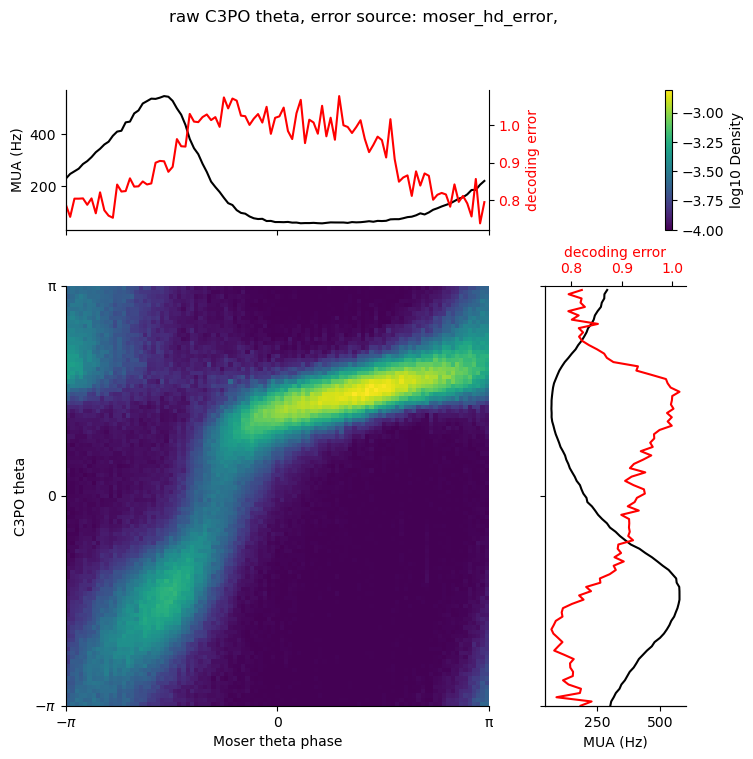

In [98]:
from c3po.analysis.analysis import interval_list_contains_ind

raw_c3po = True
error_source = "moser_hd_error"
# error_source = "moser_pos_error"
# error_source = "c3po_hd_error"


ind_valid = interval_list_contains_ind(no_gap_intervals[10:], analysis.t_interp)

t_c3po = analysis.t_interp[ind_valid]
if raw_c3po:
    theta_c3po_valid = theta_c3po_raw[ind_valid]
else:
    theta_c3po_valid = theta_c3po[ind_valid]

moser_ind = np.digitize(t_c3po, t, right=False)
moser_theta = thetaphase[moser_ind]

ind_spikes = np.digitize(t_c3po, t_spikes, right=False)
mua_aligned = mua[ind_spikes]


# ind_pred = np.digitize(t_c3po, hd_t_pred, right=False)
# error_alligned = hd_error[ind_pred]
if error_source == "moser_hd_error":
    ind_pred = np.digitize(t_c3po, t, right=False)
    error_alligned = moser_hd_error[ind_pred]
elif error_source == "moser_pos_error":
    ind_pred = np.digitize(t_c3po, t, right=False)
    error_alligned = moser_pos_error[ind_pred]
elif error_source == "c3po_hd_error":
    ind_pred = np.digitize(t_c3po, hd_t_pred, right=False)
    error_alligned = hd_error[ind_pred]
else:
    raise ValueError("Invalid error source")


H, bx, by = np.histogram2d(
    moser_theta, theta_c3po_valid, bins=np.linspace(-np.pi, np.pi, 100)
)
H = H.T
# H = H/H.sum(axis=0, keepdims=True)

# average mua vs. moser phase
mua_moser = np.zeros_like(bx[:-1])
for i in range(len(bx) - 1):
    ind = (moser_theta >= bx[i]) & (moser_theta < bx[i + 1])
    mua_moser[i] = mua_aligned[ind].mean()
mua_c3po = np.zeros_like(by[:-1])
for i in range(len(by) - 1):
    ind = (theta_c3po_valid >= by[i]) & (theta_c3po_valid < by[i + 1])
    mua_c3po[i] = mua_aligned[ind].mean()


fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 8),
    height_ratios=[1, 3],
    width_ratios=[3, 1],
    sharex="col",
    sharey="row",
)

# average error vs. moser phase
error_moser = np.zeros_like(bx[:-1])
error_moser_lo = np.zeros_like(bx[:-1])
error_moser_hi = np.zeros_like(bx[:-1])
for i in range(len(bx) - 1):
    ind = (moser_theta >= bx[i]) & (moser_theta < bx[i + 1])
    error_moser[i] = np.median(np.abs(error_alligned[ind]))
    error_moser_lo[i] = np.percentile(np.abs(error_alligned[ind]), 25)
    error_moser_hi[i] = np.percentile(np.abs(error_alligned[ind]), 75)
error_c3po = np.zeros_like(by[:-1])
error_c3po_lo = np.zeros_like(by[:-1])
error_c3po_hi = np.zeros_like(by[:-1])
for i in range(len(by) - 1):
    ind = (theta_c3po_valid >= by[i]) & (theta_c3po_valid < by[i + 1])
    error_c3po[i] = np.median(np.abs(error_alligned[ind]))
    error_c3po_lo[i] = np.percentile(np.abs(error_alligned[ind]), 25)
    error_c3po_hi[i] = np.percentile(np.abs(error_alligned[ind]), 75)


density_ax = ax[1, 0]
H = H / np.sum(H)
H = np.log10(H + 1e-4)
cb = density_ax.imshow(
    H,
    origin="lower",
    aspect="auto",
    extent=[bx[0], bx[-1], by[0], by[-1]],
    #    clim=(-3,0)
)

# cb = density_ax.imshow(H, origin='lower', aspect='auto', extent=[bx[0], bx[-1], by[0], by[-1]])
density_ax.set_xlabel("Moser theta phase")
density_ax.set_ylabel("C3PO theta")
density_ax.set_xticks([-np.pi, 0, np.pi], labels=["$-\pi$", "0", "π"])
density_ax.set_yticks([-np.pi, 0, np.pi], labels=["$-\pi$", "0", "π"])
plt.colorbar(cb, ax=ax[0, 1], label="log10 Density")

mua_moser_ax = ax[0, 0]
mua_moser_ax.plot(bx[:-1], mua_moser, color="k")
mua_moser_ax.set_ylabel("MUA (Hz)")
# mua_moser_ax.set_title('MUA vs. Moser theta phase')

mua_c3po_ax = ax[1, 1]
mua_c3po_ax.plot(mua_c3po, by[:-1], color="k")
mua_c3po_ax.set_xlabel("MUA (Hz)")
# mua_c3po_ax.set_title('MUA vs. C3PO theta')

error_moser_ax = mua_moser_ax.twinx()
error_moser_ax.plot(bx[:-1], error_moser, color="r")
# error_moser_ax.fill_between(bx[:-1], error_moser_lo, error_moser_hi, facecolor='r', alpha=0.2)
error_moser_ax.set_ylabel("decoding error", color="r")
error_moser_ax.tick_params(axis="y", labelcolor="r")

error_c3po_ax = mua_c3po_ax.twiny()
error_c3po_ax.plot(error_c3po, by[:-1], color="r")
# error_c3po_ax.fill_betweenx(by[:-1], error_c3po_lo, error_c3po_hi, facecolor='r', alpha=0.2)
error_c3po_ax.set_xlabel("decoding error", color="r")
error_c3po_ax.tick_params(axis="x", labelcolor="r")

ax[0, 1].axis("off")
for a in [
    density_ax,
    mua_moser_ax,
    mua_c3po_ax,
]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

error_moser_ax.spines["top"].set_visible(False)
error_c3po_ax.spines["right"].set_visible(False)

fig.suptitle(
    f"{'raw' if raw_c3po else 'filtered'} C3PO theta, error source: {error_source}, {'interpolated pca' *interpolated_pca}"
)

Text(0.5, 1.0, 'Error vs. Moser theta phase, error source: c3po_hd_error')

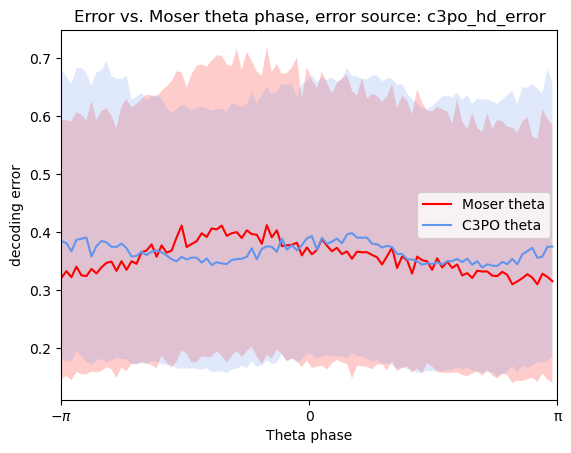

In [110]:
error_source = "moser_pos_error"
error_source = "c3po_hd_error"

if error_source == "moser_hd_error":
    ind_pred = np.digitize(t_c3po, t, right=False)
    error_alligned = moser_hd_error[ind_pred]
elif error_source == "moser_pos_error":
    ind_pred = np.digitize(t_c3po, t, right=False)
    error_alligned = moser_pos_error[ind_pred]
elif error_source == "c3po_hd_error":
    ind_pred = np.digitize(t_c3po, hd_t_pred, right=False)
    error_alligned = hd_error[ind_pred]
else:
    raise ValueError("Invalid error source")


# average error vs. moser phase
error_moser = np.zeros_like(bx[:-1])
error_moser_lo = np.zeros_like(bx[:-1])
error_moser_hi = np.zeros_like(bx[:-1])
for i in range(len(bx) - 1):
    ind = (moser_theta >= bx[i]) & (moser_theta < bx[i + 1])
    error_moser[i] = np.median(np.abs(error_alligned[ind]))
    error_moser_lo[i] = np.percentile(np.abs(error_alligned[ind]), 25)
    error_moser_hi[i] = np.percentile(np.abs(error_alligned[ind]), 75)
error_c3po = np.zeros_like(by[:-1])
error_c3po_lo = np.zeros_like(by[:-1])
error_c3po_hi = np.zeros_like(by[:-1])
for i in range(len(by) - 1):
    ind = (theta_c3po_valid >= by[i]) & (theta_c3po_valid < by[i + 1])
    error_c3po[i] = np.median(np.abs(error_alligned[ind]))
    error_c3po_lo[i] = np.percentile(np.abs(error_alligned[ind]), 25)
    error_c3po_hi[i] = np.percentile(np.abs(error_alligned[ind]), 75)

plt.plot(bx[:-1], error_moser, color="r", label="Moser theta")
plt.fill_between(bx[:-1], error_moser_lo, error_moser_hi, facecolor="r", alpha=0.2)
plt.plot(bx[:-1], error_c3po, color="cornflowerblue", label="C3PO theta")
plt.fill_between(
    bx[:-1], error_c3po_lo, error_c3po_hi, facecolor="cornflowerblue", alpha=0.2
)
plt.legend()

plt.xticks([-np.pi, 0, np.pi], labels=["$-\pi$", "0", "π"])
plt.xlim(-np.pi, np.pi)
plt.xlabel("Theta phase")
plt.ylabel("decoding error")
plt.title(f"Error vs. Moser theta phase, error source: {error_source}")

# Mark embeddings

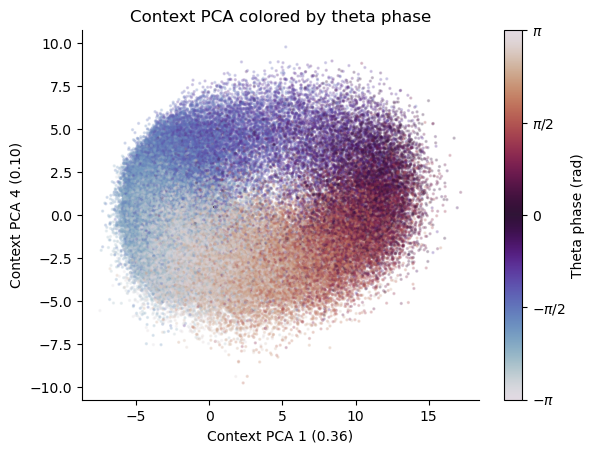

In [8]:
plot_dims = [0, 3]
# plot_dims = [0, 1]

subset = slice(None, None, 10)

fig = plt.figure()
ind_phase = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, plot_dims[0]],
    c_pca[subset][:, plot_dims[1]],
    s=2,
    alpha=0.2,
    c=thetaphase[ind_phase[subset] - 1],
    cmap="twilight",
    rasterized=True,
)
cbar = plt.colorbar(sc, label="Theta phase (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(
    f"Context PCA {plot_dims[0]+1} ({analysis.pca.explained_variance_ratio_[plot_dims[0]]:.2f})"
)
plt.ylabel(
    f"Context PCA {plot_dims[1]+1} ({analysis.pca.explained_variance_ratio_[plot_dims[1]]:.2f})"
)
plt.title("Context PCA colored by theta phase")
fig.gca().spines[["top", "right"]].set_visible(False)

# fig.savefig(figure_folder / "context_pca_theta_phase_scatter.svg")

In [9]:
W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T


t_feature = t.copy()
feature = thetaphase.copy()
c_feature_dims = [0, 3]
# c_feature_dims = [4,5]
# t_feature = t.copy()
# feature = x


# t_feature = t.copy()
# feature = thetaphase
# c_feature_dims = [0,3]


t_spike_feature_ind = np.digitize(t_spikes, t_feature)
t_spike_feature = feature[t_spike_feature_ind - 1]

feature_bins = np.linspace(-np.pi, np.pi, 100)
feature_tuning_curves = []

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i]) & (t_spike_feature < feature_bins[i + 1])
    )[0]
    # spike_counts = np.zeros(W.shape[0])
    # for bi in bin_ind:
    #     spike_counts += rates[bi]
    # feature_tuning_curves.append(spike_counts / len(bin_ind))
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves.append(spike_counts)

feature_tuning_curves = np.array(feature_tuning_curves)

# c_feature_dims = [15,13]

W_feature = W[:, c_feature_dims] * 1
W_angles = np.arctan2(W_feature[:, 0], W_feature[:, 1])
W_mag = np.linalg.norm(W_feature, 2, axis=1)
W_angles.shape

100%|██████████| 99/99 [00:02<00:00, 37.84it/s]


(460,)

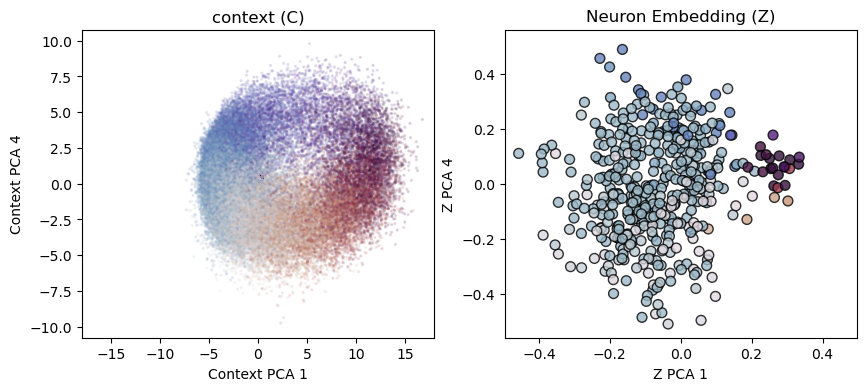

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

subset = 20
sc = ax[0].scatter(
    analysis.c_pca[::subset][:, plot_dims[0]],
    analysis.c_pca[::subset][:, plot_dims[1]],
    s=2,
    alpha=0.12,
    c=thetaphase[ind_phase[::subset] - 1],
    cmap="twilight",
    rasterized=True,
)
scale = 1

color = np.argmax(feature_tuning_curves, axis=0)
color = feature_bins[:-1][color]
sc = plt.scatter(
    W_feature[:, 0] * scale,
    W_feature[:, 1] * scale,
    c=color,
    edgecolor="k",
    cmap="twilight",
    alpha=0.8,
    s=50,
)


ax[0].set_xlabel(f"Context PCA {c_feature_dims[0]+1}")
ax[0].set_ylabel(f"Context PCA {c_feature_dims[1]+1}")

ax[1].set_xlabel(f"Z PCA {c_feature_dims[0]+1}")
ax[1].set_ylabel(f"Z PCA {c_feature_dims[1]+1}")

ax[0].set_title("context (C)")
ax[1].set_title("Neuron Embedding (Z)")

for a in ax:
    xlim = np.max(np.abs(a.get_xlim()))
    ylim = np.max(np.abs(a.get_ylim()))
    a.set_xlim(-xlim, xlim)
    a.set_ylim(-ylim, ylim)

# ind_analyze = np.where(W_feature[:, 0] > 0.2)[0]
# ind_ref = np.where(W_feature[:, 0] <= 0.2)[0]
# color = np.argmax(feature_tuning_curves, axis=0)
# color = feature_bins[:-1][color]
# sc = plt.scatter(
#     W_feature[ind_analyze, 0] * scale,
#     W_feature[ind_analyze, 1] * scale,
#     c=color[ind_analyze],
#     edgecolor="k",
#     cmap="twilight",
#     alpha=0.8,
#     s=50,
# )
# plt.scatter(W_feature[:, 0]*scale, W_feature[:, 1]*scale, color="k", s=10)

In [14]:
mua_analyze = rates[:, ind_analyze].sum(axis=1)
mua_ref = rates[:, ind_ref].sum(axis=1)
mua_all = rates.sum(axis=1)

spike_phase_ind = np.digitize(t_spikes, t)
spike_phases = thetaphase[spike_phase_ind - 1]

bins = np.linspace(-np.pi, np.pi, 20)
# average mua vs. moser phase
mua_ref_phase = np.zeros_like(bins[:-1])
mua_analyze_phase = np.zeros_like(bins[:-1])
mua_all_phase = np.zeros_like(bins[:-1])
for i in range(len(bins) - 1):
    ind = (spike_phases >= bins[i]) & (spike_phases < bins[i + 1])
    mua_ref_phase[i] = mua_ref[ind].mean()
    mua_analyze_phase[i] = mua_analyze[ind].mean()
    mua_all_phase[i] = mua_all[ind].mean()

mua_ref_phase = mua_ref_phase / np.mean(mua_ref)
mua_analyze_phase = mua_analyze_phase / np.mean(mua_analyze)
mua_all_phase = mua_all_phase / np.mean(mua_all)

# ind_plot = slice(5000,5500)
# fig = plt.figure()
# ax = fig.gca()
# ax_ref = ax.twinx()
# ax.plot(t[ind_plot], mua_analyze[ind_plot], label="analyze", color="firebrick")
# ax_ref.plot(t[ind_plot], mua_ref[ind_plot], label="ref")

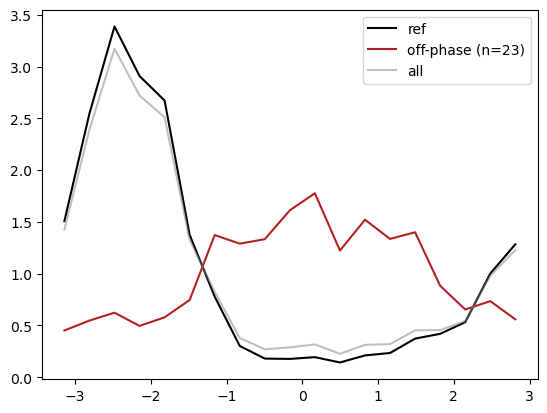

In [15]:
plt.plot(bins[:-1], mua_ref_phase, label="ref", color="k")
plt.plot(
    bins[:-1],
    mua_analyze_phase,
    label=f"off-phase (n={ind_analyze.size})",
    color="firebrick",
)
plt.plot(bins[:-1], mua_all_phase, label="all", color="gray", alpha=0.5)
plt.legend()

In [11]:
mat_fields(units["mec"][0])

('id',
 'ks2Label',
 'location',
 'meanRate',
 'nSpikes',
 'probeId',
 'shank',
 'shankPos',
 'spikeInds',
 'spikeTimes',
 'wvExtent',
 'lmtF',
 'rmc',
 'rmf',
 'smdl',
 'wv',
 'cellType',
 'acorrClu',
 'isGrid',
 'acorrCluId')

In [ ]:
# mat_fields(units["mec"][0])
# unit_info = dict()
# for unit_feature in mat_fields(units["mec"][0]):
#     unit_info[unit_feature] = units["mec"][0][unit_feature].flatten()
# unit_info

In [34]:
unit_feature = "wvExtent"
unit_feature = "isGrid"
unit_feature = "acorrCluId"
unit_feature = "shank"
units["mec"][0][unit_feature][0]

array([array([[3]], dtype=uint8)], dtype=object)

Text(0, 0.5, 'Context PCA 4')

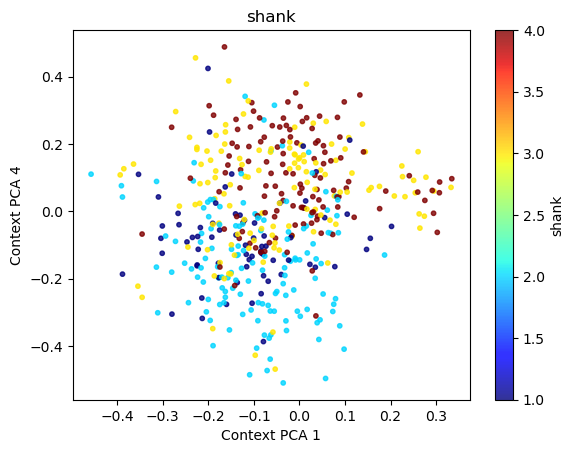

In [ ]:
# color = np.argmax(feature_tuning_curves, axis=0)
# color = feature_bins[:-1][color]
color = units["mec"][0][unit_feature].flatten()
# color = [len(s) for s in spikes]
sc = plt.scatter(
    W_feature[:, 0] * scale,
    W_feature[:, 1] * scale,
    c=color,
    # edgecolor="k",
    # cmap=p,
    cmap="jet",
    alpha=0.8,
    s=10,
)
plt.colorbar(label=unit_feature)
plt.title("shank")

plt.xlabel(f"Context PCA {c_feature_dims[0]+1}")
plt.ylabel(f"Context PCA {c_feature_dims[1]+1}")

array([3, 3, 1, 4, 1, 2, 3, 3, 1, 1, 2, 2, 4, 2, 1, 4, 1, 4, 2, 2, 3, 3,
       3, 2, 4, 3, 2, 1, 3, 4, 3, 3, 4, 3, 2, 4, 3, 3, 2, 2, 1, 4, 2, 3,
       4, 3, 2, 4, 3, 3, 3, 4, 3, 4, 4, 4, 4, 3, 4, 4, 1, 2, 2, 1, 1, 1,
       3, 2, 2, 4, 4, 4, 4, 4, 1, 4, 3, 3, 1, 3, 3, 3, 3, 2, 3, 3, 2, 3,
       4, 3, 3, 4, 3, 3, 4, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 3, 1, 4,
       4, 2, 1, 1, 4, 1, 3, 4, 1, 3, 2, 4, 4, 1, 1, 1, 2, 3, 3, 4, 4, 3,
       3, 3, 2, 1, 3, 3, 2, 1, 4, 4, 3, 1, 3, 4, 4, 2, 3, 4, 2, 3, 3, 4,
       3, 1, 2, 1, 2, 1, 4, 1, 2, 1, 4, 4, 4, 2, 2, 1, 3, 2, 2, 3, 2, 4,
       1, 1, 3, 2, 4, 4, 3, 1, 4, 3, 4, 4, 2, 1, 3, 3, 3, 4, 3, 4, 3, 1,
       1, 4, 4, 3, 1, 4, 3, 3, 3, 3, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 4, 4,
       4, 1, 3, 3, 2, 3, 4, 4, 2, 2, 3, 1, 4, 2, 4, 4, 1, 4, 1, 3, 2, 2,
       2, 2, 3, 4, 2, 3, 2, 4, 3, 1, 2, 1, 1, 4, 3, 3, 3, 4, 4, 1, 4, 3,
       1, 1, 3, 3, 3, 4, 2, 2, 2, 3, 4, 2, 2, 1, 2, 3, 2, 4, 4, 4, 4, 3,
       3, 2, 4, 2, 3, 4, 1, 4, 4, 3, 1, 2, 1, 4, 3,

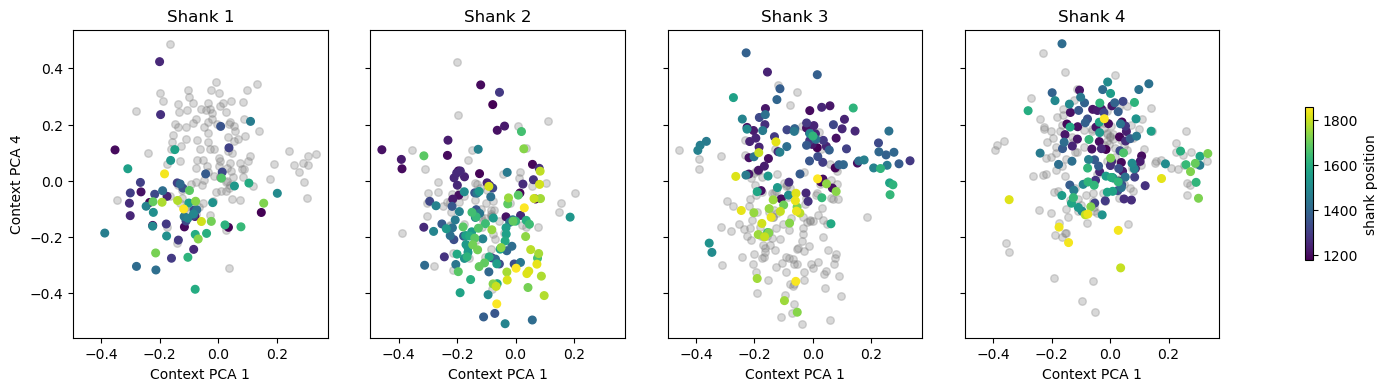

In [ ]:
shank = np.array([np.squeeze(ss[0][0]) for ss in units["mec"][0]["shank"]])
shank_pos = units["mec"][0]["shankPos"].flatten()

# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharex=True, sharey=True)
fig, ax = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(16, 4),
    sharex=True,
    sharey=True,
    width_ratios=[1, 1, 1, 1, 0.2],
)
ax = np.ravel(ax)
for i, sh in enumerate(np.unique(shank)):
    ax[i].scatter(
        W_feature[ind, 0] * scale,
        W_feature[ind, 1] * scale,
        facecolor="grey",
        edgecolor=None,
        s=30,
        alpha=0.3,
        label=f"shank {sh}",
    )

    ind = shank == sh

    cb = ax[i].scatter(
        W_feature[ind, 0] * scale,
        W_feature[ind, 1] * scale,
        c=shank_pos[ind],
        s=30,
        alpha=1,
        label=f"shank {sh}",
    )
    ax[i].set_title(f"Shank {sh}")

ax[-1].set_visible(False)
fig.colorbar(cb, ax=ax[-1], label="shank position")

ax[0].set_ylabel(f"Context PCA {c_feature_dims[1]+1}")
for a in ax:
    a.set_xlabel(f"Context PCA {c_feature_dims[0]+1}")

In [ ]:
angle_bins = np.linspace(-np.pi, np.pi, 7)
angle_bins = np.percentile(W_angles, np.linspace(0, 100, 4))

angle_inds = []
for i in range(len(angle_bins) - 1):
    ind = (W_angles >= angle_bins[i]) & (W_angles < angle_bins[i + 1])
    angle_inds.append(ind)

angle_muas = []
for ind in angle_inds:
    mua = rates[:, ind].sum(axis=1)
    angle_muas.append(mua / mua.mean())
angle_muas = np.array(angle_muas).T

IndexError: boolean index did not match indexed array along axis 0; size of axis is 2659851 but size of corresponding boolean axis is 1273703

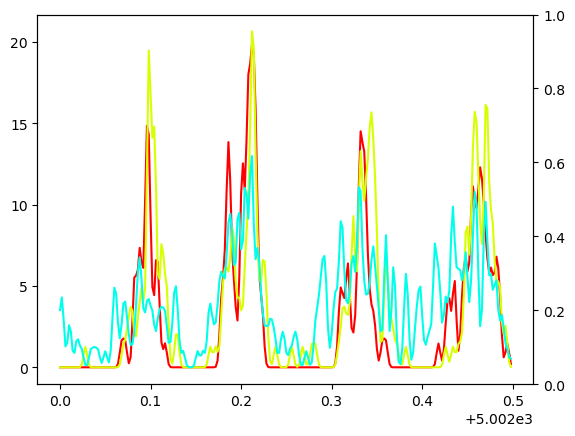

In [ ]:
st = 5002
t_plot = (st, st + 0.5)

fig = plt.figure()
ax = fig.gca()
ind_plot = (t_spikes >= t_plot[0]) & (t_spikes < t_plot[1])

for i in range(angle_muas.shape[1]):
    color = plt.cm.hsv((angle_bins[i] + np.pi) / (2 * np.pi))
    plt.plot(
        t_spikes[ind_plot], angle_muas[ind_plot, i], label=f"angle bin {i+1}", c=color
    )


theta_ax = ax.twinx()
# ind_phase = np.logical_and(t >= t_plot[0], t < t_plot[1])
# theta_ax.plot(t[ind_phase], thetaphase[ind_phase], label="theta", c= "k")
ind_phase = np.logical_and(analysis.t >= t_plot[0], analysis.t < t_plot[1])
theta_ax.plot(
    analysis.t[ind_phase],
    theta_c3po_raw[ind_phase],
    label="c3po theta",
    c="cornflowerblue",
)